# AlgoSense AI

## 1. Agent concept

| Item | Description |
|------|-------------|
| **Name** | AlgoSense AI |
| **Role** | LeetCode interview prep learning agent |
| **Input** | User learning state + user-selected **Study Mode** + mode-specific answers (MCQ or free-text) |
| **Output** | Automatic evaluation, mistake analysis, weakness tracking, wrong-note updates, spaced repetition, and next recommendation |

## 2. Target graph (full design)

```
[START]
   |
   v
[Select Study Mode]
   |
   v
[Problem Curation Node]
(interview frequency + user weaknesses + review priority + selected mode)
   |
   v
[Problem Card Generator]
   |
   +--------------------+------------------------+--------------------+
   |                    |                        |
   v                    v                        v
[Pattern Mode]      [Big-O Drill Mode]    [Follow-up Mode]
   |                    |                        |
   v                    v                        v
[Answer Intake]     [Answer Intake]        [Question Generator]
   |                    |                        |
   v                    v                        v
[Evaluate Answer]   [Evaluate Big-O]       [User Response Intake]
   |                    |                        |
   +----------+---------+-----------+------------+
              |                     |
              v                     v
       [Mistake Diagnosis]   [Follow-up Evaluation]
              |                     |
              +----------+----------+
                         |
                         v
               [Weakness Tracker]
                         |
                         v
                [Spaced Repetition Scheduler]
                         |
                         v
                 [Wrong Note Update]
                         |
                         v
               [Recommend Next Card]
                         |
                         v
                 [Continue Session?]
                    |           |
                   Yes          No
                    |           |
                    v           v
            [Problem Curation Node] [END]
```

## 3. Runnable sample

End-to-end invocation lives in the **final run cell** of this notebook (requires `OPENAI_API_KEY`).

## 4. Notes
- Intake nodes are **MCQ by design** for easy UI integration.
- Follow-up mode uses **free-text** user response intake.


In [18]:
from __future__ import annotations

import json
import os
import random
from typing import Any, Dict, List, Optional, TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph


# Heavily-used LLM for this workflow
llm = init_chat_model("openai:gpt-4o")


CANONICAL_CATEGORIES = [
    "array",
    "hashmap",
    "two_pointers",
    "stack",
    "graph",
    "dfs_bfs",
    "dp",
    "greedy",
    "binary_search",
    "sorting",
    "backtracking",
    "dynamic_programming",
    "math",
    "string",
    "tree",
    "linked_list",
    "bit_manipulation",
    "two_pointers",
    "sliding_window",
    "stack",
    "queue",
    "heap",
]

BIG_O_CHOICES = [
    "O(1)",
    "O(log n)",
    "O(n)",
    "O(n log n)",
    "O(n^2)",
    "O(n^3)",
    "O(2^n)",
]


def _canonicalize_bigo(raw: str) -> str:
    """Map common Big-O variants to the canonical strings in BIG_O_CHOICES."""

    s = str(raw).strip().lower().replace(" ", "")

    mapping = {
        "o(1)": "O(1)",
        "o(logn)": "O(log n)",
        "o(n)": "O(n)",
        "o(nlogn)": "O(n log n)",
        "o(nlgn)": "O(n log n)",
        "o(n^2)": "O(n^2)",
        "o(n²)": "O(n^2)",
        "o(n^3)": "O(n^3)",
        "o(n³)": "O(n^3)",
        "o(2^n)": "O(2^n)",
        "o(2ⁿ)": "O(2^n)",
    }

    canonical = mapping.get(s)
    if canonical:
        return canonical

    raw_str = str(raw).strip()
    if raw_str in BIG_O_CHOICES:
        return raw_str

    return raw_str


class Problem(TypedDict):
    id: str
    title: str
    slug: str
    url: str
    categories: List[str]
    difficulty: str  # Easy/Medium/Hard
    interview_freq: float  # 0~1 (LLM-estimated proxy)


class UserProfile(TypedDict):
    weakness_by_category: Dict[str, float]  # higher = weaker
    solved_ids: List[str]
    wrong_ids: List[str]


class LearningState(TypedDict, total=False):
    user_profile: UserProfile
    due_review_ids: List[str]

    # study mode (MCQ)
    study_mode_mcq: Dict[str, Any]
    study_mode_selected_index: int
    study_mode: str  # 'pattern' | 'bigo' | 'followup'

    # follow-up drill mode
    followup_questions: List[str]
    followup_user_response: str
    followup_is_correct: bool

    # session control
    session_day: int
    turn_index: int
    max_turns: int
    continue_session: bool

    # spaced repetition + notes
    review_schedule: Dict[str, Dict[str, Any]]  # problem_id -> {due_day, interval, ease}
    wrong_notes: Dict[str, List[Dict[str, Any]]]  # problem_id -> list of notes

    # produced by LLM
    problem_pool: List[Problem]

    # produced by curation
    selected_problem: Problem

    # produced by LLM
    problem_card: Dict[str, Any]

    # Pattern mode (Category MCQ)
    category_mcq: Dict[str, Any]  # {prompt, options: [...]} 
    category_selected_index: int
    category_selected: str
    expected_category: str
    category_is_correct: bool

    # Best solution + expected Big-O
    best_solution: Dict[str, Any]
    expected_bigo_time: str
    expected_bigo_space: str

    # Big-O drill mode (Big-O MCQ)
    bigo_mcq_time: Dict[str, Any]
    bigo_mcq_space: Dict[str, Any]
    bigo_selected_time_index: int
    bigo_selected_space_index: int
    bigo_selected_time: str
    bigo_selected_space: str
    bigo_is_correct: bool

    # Post-analysis
    mistake_diagnosis: Dict[str, Any]

    # recommendation
    recommended_next_card: Dict[str, Any]


In [19]:
DEFAULT_PROFILE: UserProfile = {
    "weakness_by_category": {
        "hashmap": 0.6,
        "two_pointers": 0.9,
        "stack": 0.2,
        "graph": 0.7,
        "dfs_bfs": 0.7,
        "array": 0.3,
        "sorting": 0.4,
    },
    "solved_ids": [],
    "wrong_ids": ["lc_20_valid_parentheses"],
}


def _require_openai_key() -> None:
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError(
            "OPENAI_API_KEY is not set. Put it in your environment (recommended) or in a local .env file."
        )


def _json_from_llm(text: str) -> Any:
    """Extract JSON from an LLM response (supports fenced or plain JSON)."""
    s = text.strip()
    if "```" in s:
        # take the first fenced block
        parts = s.split("```")
        if len(parts) >= 3:
            s = parts[1].strip()
            if s.startswith("json"):
                s = s[4:].strip()
    return json.loads(s)


def generate_problem_pool_node(state: LearningState) -> LearningState:
    """Generate a fresh candidate pool via LLM (no hand-written sample pool)."""

    _require_openai_key()

    profile = state.get("user_profile", DEFAULT_PROFILE)
    weakness = profile.get("weakness_by_category", {})
    solved = profile.get("solved_ids", [])

    prompt = {
        "role": "user",
        "content": (
            "Generate a candidate pool of 12 LeetCode problems as STRICT JSON. "
            "Focus on interview-popular problems, but bias toward the user's weak categories.\n\n"
            f"User weakness_by_category (higher=weaker): {weakness}\n"
            f"Already solved ids (avoid repeating): {solved}\n\n"
            "Return ONLY valid JSON: an array of objects with fields:\n"
            "- id: stable string id (e.g., 'lc_two_sum')\n"
            "- title\n"
            "- slug (leetcode slug, e.g., 'two-sum')\n"
            "- url (https://leetcode.com/problems/<slug>/)\n"
            "- categories (array of canonical tags like: array, hashmap, two_pointers, stack, graph, dfs_bfs, dp, greedy, binary_search, sorting)\n"
            "- difficulty (Easy|Medium|Hard)\n"
            "- interview_freq (float 0..1, your estimate as a proxy for popularity)\n\n"
            "Rules:\n"
            "- Do not include explanations, markdown, or extra keys.\n"
            "- Ensure slugs and urls are consistent.\n"
        ),
    }

    resp = llm.invoke([prompt])
    pool = _json_from_llm(getattr(resp, "content", str(resp)))

    if not isinstance(pool, list) or not pool:
        raise ValueError("LLM returned an empty/non-list problem pool")

    # minimal validation / normalization
    normalized: List[Problem] = []
    for item in pool:
        if not isinstance(item, dict):
            continue
        if not all(k in item for k in ["id", "title", "slug", "url", "categories", "difficulty", "interview_freq"]):
            continue
        item["interview_freq"] = float(item["interview_freq"])
        normalized.append(item)  # type: ignore[arg-type]

    if not normalized:
        raise ValueError("LLM returned pool, but none passed validation")

    return {**state, "user_profile": profile, "problem_pool": normalized}


In [20]:
def _weakness_score(problem: Problem, weakness_by_category: Dict[str, float]) -> float:
    if not problem.get("categories"):
        return 0.0
    vals = [float(weakness_by_category.get(cat, 0.0)) for cat in problem["categories"]]
    return sum(vals) / max(1, len(vals))


def problem_curation_node(state: LearningState) -> LearningState:
    """Pick the next problem from the LLM-generated pool using transparent scoring."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    pool = state["problem_pool"]  # generated by LLM node
    due_ids = set(state.get("due_review_ids", []))
    solved = set(profile.get("solved_ids", []))

    best: Optional[Problem] = None
    best_score = -1e9

    for p in pool:
        if p["id"] in solved:
            continue

        freq = float(p.get("interview_freq", 0.0))
        weak = _weakness_score(p, profile.get("weakness_by_category", {}))
        due = 1.0 if p["id"] in due_ids else 0.0

        # MVP weights (easy to explain)
        score = 0.50 * freq + 0.35 * weak + 0.15 * due

        if score > best_score:
            best_score = score
            best = p

    if best is None:
        best = pool[0]

    return {**state, "selected_problem": best}


In [21]:
def _pick_mcq_options(correct: str, universe: List[str], k: int = 4) -> List[str]:
    if correct not in universe:
        universe = [correct] + universe
    distractors = [x for x in universe if x != correct]
    random.shuffle(distractors)
    options = [correct] + distractors[: max(0, k - 1)]
    random.shuffle(options)
    return options


def category_answer_intake_node(state: LearningState) -> LearningState:
    """Multiple-choice category question.

    In a real UI, you would render options and collect the user's choice.
    In this notebook, set `category_selected_index` in the initial state to simulate.
    """

    p = state["selected_problem"]

    # Use the problem's tags as a strong prior for the correct category,
    # but still present a standardized MCQ.
    correct_hint = p["categories"][0] if p.get("categories") else "array"
    options = _pick_mcq_options(correct_hint, CANONICAL_CATEGORIES, k=5)

    mcq = {
        "prompt": f"Select the best primary solution category for: {p['title']}",
        "options": options,
    }

    idx = int(state.get("category_selected_index", 0))
    idx = max(0, min(idx, len(options) - 1))
    selected = options[idx]

    return {**state, "category_mcq": mcq, "category_selected": selected}


def category_evaluation_node(state: LearningState) -> LearningState:
    """Evaluate the chosen category using the LLM (objective judgement)."""

    _require_openai_key()

    p = state["selected_problem"]
    selected = state["category_selected"]

    prompt = {
        "role": "user",
        "content": (
            "You are evaluating a candidate's solution CATEGORY choice for a LeetCode interview question.\n\n"
            f"Problem: {p}\n\n"
            f"Candidate selected category: {selected}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- expected_category: one of [array, hashmap, two_pointers, stack, graph, dfs_bfs, dp, greedy, binary_search, sorting]\n"
            "- is_correct: boolean\n"
            "- brief_reason: one sentence\n"
        ),
    }

    resp = llm.invoke([prompt])
    out = _json_from_llm(getattr(resp, "content", str(resp)))

    expected = str(out.get("expected_category", ""))
    is_correct = bool(out.get("is_correct", False))

    return {
        **state,
        "expected_category": expected,
        "category_is_correct": is_correct,
        "mistake_diagnosis": {
            "category": {
                "selected": selected,
                "expected": expected,
                "reason": out.get("brief_reason", ""),
            }
        },
    }


def best_solution_presenter_node(state: LearningState) -> LearningState:
    """Present the best solution and define the expected Big-O (time+space)."""

    _require_openai_key()

    p = state["selected_problem"]

    prompt = {
        "role": "user",
        "content": (
            "Provide the best (interview-optimal) approach for the LeetCode problem below.\n\n"
            f"Problem: {p}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- approach_name\n"
            "- high_level_steps (array of 4-7 short steps)\n"
            "- key_data_structures (array)\n"
            "- expected_time_bigo (one of: O(1), O(log n), O(n), O(n log n), O(n^2), O(n^3), O(2^n))\n"
            "- expected_space_bigo (one of the same set)\n"
            "- why_this_is_optimal (1-2 sentences)\n"
        ),
    }

    resp = llm.invoke([prompt])
    out = _json_from_llm(getattr(resp, "content", str(resp)))

    time_bigo = _canonicalize_bigo(str(out.get("expected_time_bigo", "")))
    space_bigo = _canonicalize_bigo(str(out.get("expected_space_bigo", "")))

    return {
        **state,
        "best_solution": out,
        "expected_bigo_time": time_bigo,
        "expected_bigo_space": space_bigo,
    }


def bigo_answer_intake_node(state: LearningState) -> LearningState:
    """Multiple-choice intake for BOTH time and space Big-O."""

    expected_t = state.get("expected_bigo_time", "O(n)")
    expected_s = state.get("expected_bigo_space", "O(n)")

    time_options = _pick_mcq_options(expected_t, BIG_O_CHOICES, k=5)
    space_options = _pick_mcq_options(expected_s, BIG_O_CHOICES, k=5)

    time_mcq = {
        "prompt": "Select the expected TIME complexity of the optimal solution:",
        "options": time_options,
    }
    space_mcq = {
        "prompt": "Select the expected SPACE complexity of the optimal solution:",
        "options": space_options,
    }

    ti = int(state.get("bigo_selected_time_index", 0))
    si = int(state.get("bigo_selected_space_index", 0))

    ti = max(0, min(ti, len(time_options) - 1))
    si = max(0, min(si, len(space_options) - 1))

    return {
        **state,
        "bigo_mcq_time": time_mcq,
        "bigo_mcq_space": space_mcq,
        "bigo_selected_time": time_options[ti],
        "bigo_selected_space": space_options[si],
    }


def _normalize_bigo(s: str) -> str:
    return str(s).replace(" ", "").lower()


def bigo_evaluation_node(state: LearningState) -> LearningState:
    """Objective evaluation of Big-O answers (exact match after normalization)."""

    expected_t = _normalize_bigo(state.get("expected_bigo_time", ""))
    expected_s = _normalize_bigo(state.get("expected_bigo_space", ""))
    got_t = _normalize_bigo(state.get("bigo_selected_time", ""))
    got_s = _normalize_bigo(state.get("bigo_selected_space", ""))

    ok = (expected_t == got_t) and (expected_s == got_s)

    return {
        **state,
        "bigo_is_correct": ok,
    }


def select_study_mode_node(state: LearningState) -> LearningState:
    """Select study mode (MCQ). In this notebook we simulate user choice by index."""

    options = [
        {"id": "pattern", "label": "Pattern Mode (pick category)"},
        {"id": "bigo", "label": "Big-O Drill Mode (pick time/space)"},
        {"id": "followup", "label": "Follow-up Mode (free-text interview Q)"},
    ]

    idx = int(state.get("study_mode_selected_index", 0))
    idx = max(0, min(idx, len(options) - 1))
    selected = options[idx]["id"]

    return {
        **state,
        "study_mode_mcq": {"prompt": "Select a study mode", "options": options},
        "study_mode": selected,
    }


def _mode_router(state: LearningState) -> str:
    mode = str(state.get("study_mode", "pattern")).strip().lower()
    if mode in {"pattern", "bigo", "followup"}:
        return mode
    return "pattern"


def followup_question_generator_node(state: LearningState) -> LearningState:
    """Generate 2-3 interview-style follow-up questions for the current problem."""

    _require_openai_key()

    p = state["selected_problem"]

    prompt = {
        "role": "user",
        "content": (
            "Generate 2-3 short interview follow-up questions for the given LeetCode problem.\n"
            "Focus on edge cases, trade-offs, or alternative approaches.\n\n"
            f"Problem: {p}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- questions (array of 2-3 strings)\n"
        ),
    }

    resp = llm.invoke([prompt])
    data = _json_from_llm(getattr(resp, "content", str(resp)))
    questions = data.get("questions") if isinstance(data, dict) else None
    if not isinstance(questions, list):
        questions = []

    return {**state, "followup_questions": [str(q) for q in questions][:3]}


def followup_user_response_intake_node(state: LearningState) -> LearningState:
    """Intake a free-text response (simulated via `followup_user_response`)."""

    # In a real UI, you'd collect user text here.
    return state


def followup_evaluation_node(state: LearningState) -> LearningState:
    """Evaluate follow-up response as correct/acceptable vs not."""

    _require_openai_key()

    p = state["selected_problem"]
    questions = state.get("followup_questions", [])
    user_resp = state.get("followup_user_response", "")

    prompt = {
        "role": "user",
        "content": (
            "Evaluate the candidate's response to the follow-up interview questions.\n\n"
            f"Problem: {p}\n\n"
            f"Questions: {questions}\n\n"
            f"User response: {user_resp}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- is_correct (boolean)\n"
            "- short_feedback (string)\n"
        ),
    }

    resp = llm.invoke([prompt])
    data = _json_from_llm(getattr(resp, "content", str(resp)))

    is_correct = bool(data.get("is_correct")) if isinstance(data, dict) else False

    return {**state, "followup_is_correct": is_correct, "followup_feedback": data}


def mistake_diagnosis_node(state: LearningState) -> LearningState:
    """Diagnose mistakes using the LLM (Pattern/Big-O modes only).

    This node is mode-tolerant:
    - Pattern mode may not have Big-O fields.
    - Big-O drill mode may not have category fields.
    """

    _require_openai_key()

    cat_ok = state.get("category_is_correct")
    bigo_ok = state.get("bigo_is_correct")

    # If this mode didn't run category/bigo, skip diagnosis.
    if cat_ok is None and bigo_ok is None:
        return {**state, "mistake_diagnosis": {"summary": "Skipped (follow-up mode)."}}

    ok = True
    if cat_ok is not None:
        ok = ok and bool(cat_ok)
    if bigo_ok is not None:
        ok = ok and bool(bigo_ok)

    if ok:
        return {
            **state,
            "mistake_diagnosis": {
                **state.get("mistake_diagnosis", {}),
                "summary": "No mistakes detected for this turn.",
            },
        }

    p = state["selected_problem"]

    lines = ["Diagnose the candidate's mistakes based on the provided answers.", "", f"Problem: {p}", ""]

    if cat_ok is not None:
        lines.append(f"Category selected: {state.get('category_selected')}")
        lines.append(f"Category expected: {state.get('expected_category')}")

    if bigo_ok is not None:
        lines.append(
            f"Big-O selected (time, space): {(state.get('bigo_selected_time'), state.get('bigo_selected_space'))}"
        )
        lines.append(
            f"Big-O expected (time, space): {(state.get('expected_bigo_time'), state.get('expected_bigo_space'))}"
        )

    lines.extend(
        [
            "",
            "Return ONLY strict JSON with keys:",
            "- root_causes (array of 2-4 short items)",
            "- quick_fix (array of 2-4 short actions)",
            "- follow_up_questions (array of 2-3 interview follow-ups)",
        ]
    )

    prompt = {"role": "user", "content": "\n".join(lines)}

    resp = llm.invoke([prompt])
    diag = _json_from_llm(getattr(resp, "content", str(resp)))

    return {
        **state,
        "mistake_diagnosis": {
            **state.get("mistake_diagnosis", {}),
            "analysis": diag,
        },
    }


def weakness_tracker_node(state: LearningState) -> LearningState:
    """Update weakness weights based on mistakes (simple, deterministic heuristic)."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    weakness = dict(profile.get("weakness_by_category", {}))

    selected_problem = state.get("selected_problem")
    cats = selected_problem.get("categories", []) if selected_problem else []

    mode = str(state.get("study_mode", "pattern"))

    if mode == "followup":
        if state.get("followup_is_correct") is False:
            for c in cats:
                weakness[c] = min(1.0, float(weakness.get(c, 0.0)) + 0.03)
    else:
        # If category wrong: increase weakness for expected category + involved categories
        if state.get("category_is_correct") is False:
            expected = state.get("expected_category")
            if expected:
                weakness[expected] = min(1.0, float(weakness.get(expected, 0.0)) + 0.08)
            for c in cats:
                weakness[c] = min(1.0, float(weakness.get(c, 0.0)) + 0.04)

        # If Big-O wrong: small bump across involved categories (complexity intuition)
        if state.get("bigo_is_correct") is False:
            for c in cats:
                weakness[c] = min(1.0, float(weakness.get(c, 0.0)) + 0.03)

    new_profile: UserProfile = {
        **profile,
        "weakness_by_category": weakness,
    }

    return {**state, "user_profile": new_profile}


def spaced_repetition_scheduler_node(state: LearningState) -> LearningState:
    """Very small SR scheduler (SM-2 inspired, simplified).

    Updates:
    - review_schedule[problem_id] = {due_day, interval, ease}
    - due_review_ids: list of problems due today (session_day)
    """

    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]
    day = int(state.get("session_day", 0))

    schedule = dict(state.get("review_schedule", {}))
    entry = dict(schedule.get(pid, {"due_day": day, "interval": 1, "ease": 2.3}))

    mode = str(state.get("study_mode", "pattern"))

    if mode == "followup":
        success = bool(state.get("followup_is_correct", False))
    elif mode == "bigo":
        success = bool(state.get("bigo_is_correct", False))
    else:
        success = bool(state.get("category_is_correct", False))

    if success:
        ease = float(entry.get("ease", 2.3))
        interval = int(entry.get("interval", 1))
        interval = max(1, int(round(interval * ease)))
        due_day = day + interval
        entry.update({"ease": min(2.8, ease + 0.05), "interval": interval, "due_day": due_day})
    else:
        entry.update({"ease": max(1.7, float(entry.get("ease", 2.3)) - 0.2), "interval": 1, "due_day": day + 1})

    schedule[pid] = entry

    due_today = [k for k, v in schedule.items() if int(v.get("due_day", 10**9)) <= day]

    return {**state, "review_schedule": schedule, "due_review_ids": due_today}


def wrong_note_update_node(state: LearningState) -> LearningState:
    """Store per-problem wrong notes and update user history + turn counter."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]

    # --- notes
    notes = dict(state.get("wrong_notes", {}))
    notes_for_problem = list(notes.get(pid, []))

    mode = str(state.get("study_mode", "pattern"))

    if mode == "followup":
        success = bool(state.get("followup_is_correct", False))
        if not success:
            notes_for_problem.append(
                {
                    "session_day": int(state.get("session_day", 0)),
                    "problem": p,
                    "mode": mode,
                    "followup": {
                        "questions": state.get("followup_questions"),
                        "user_response": state.get("followup_user_response"),
                        "feedback": state.get("followup_feedback"),
                    },
                }
            )
    elif mode == "bigo":
        success = bool(state.get("bigo_is_correct", False))
        if not success:
            notes_for_problem.append(
                {
                    "session_day": int(state.get("session_day", 0)),
                    "problem": p,
                    "mode": mode,
                    "bigo": {
                        "selected": {
                            "time": state.get("bigo_selected_time"),
                            "space": state.get("bigo_selected_space"),
                        },
                        "expected": {
                            "time": state.get("expected_bigo_time"),
                            "space": state.get("expected_bigo_space"),
                        },
                    },
                    "diagnosis": state.get("mistake_diagnosis"),
                }
            )
    else:
        success = bool(state.get("category_is_correct", False))
        if not success:
            notes_for_problem.append(
                {
                    "session_day": int(state.get("session_day", 0)),
                    "problem": p,
                    "mode": mode,
                    "category": {
                        "selected": state.get("category_selected"),
                        "expected": state.get("expected_category"),
                    },
                    "diagnosis": state.get("mistake_diagnosis"),
                }
            )

    notes[pid] = notes_for_problem

    # --- user history
    solved_ids = list(profile.get("solved_ids", []))
    wrong_ids = list(profile.get("wrong_ids", []))

    if success:
        if pid not in solved_ids:
            solved_ids.append(pid)
    else:
        if pid not in wrong_ids:
            wrong_ids.append(pid)

    new_profile: UserProfile = {**profile, "solved_ids": solved_ids, "wrong_ids": wrong_ids}

    # --- advance turn
    turn_index = int(state.get("turn_index", 0)) + 1

    return {**state, "wrong_notes": notes, "user_profile": new_profile, "turn_index": turn_index}


def recommend_next_card_node(state: LearningState) -> LearningState:
    """Recommend what to study next (simple heuristic, UI-friendly dict)."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    weakness = profile.get("weakness_by_category", {})
    due = list(state.get("due_review_ids", []))

    weakest_cat = None
    weakest_val = -1.0
    for k, v in weakness.items():
        try:
            fv = float(v)
        except Exception:
            continue
        if fv > weakest_val:
            weakest_cat, weakest_val = k, fv

    rec = {
        "title": "Next recommendation",
        "due_review_ids": due,
        "focus_category": weakest_cat,
        "reason": "Prioritize due reviews, then weakest category.",
        "study_mode": state.get("study_mode"),
    }

    return {**state, "recommended_next_card": rec}


def next_problem_selector_node(state: LearningState) -> LearningState:
    """Hook point for recommendation logic.

    The actual next problem is picked by looping back to `curate_problem`.
    """

    return state


def update_user_learning_state_node(state: LearningState) -> LearningState:
    """Update solved/wrong history and advance turn counters."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]

    solved_ids = list(profile.get("solved_ids", []))
    wrong_ids = list(profile.get("wrong_ids", []))

    cat_ok = bool(state.get("category_is_correct", False))
    bigo_ok = bool(state.get("bigo_is_correct", False))
    success = cat_ok and bigo_ok

    if success:
        if pid not in solved_ids:
            solved_ids.append(pid)
    else:
        if pid not in wrong_ids:
            wrong_ids.append(pid)

    new_profile: UserProfile = {**profile, "solved_ids": solved_ids, "wrong_ids": wrong_ids}

    turn_index = int(state.get("turn_index", 0)) + 1
    max_turns = int(state.get("max_turns", 1))

    return {**state, "user_profile": new_profile, "turn_index": turn_index, "max_turns": max_turns}


def continue_session_node(state: LearningState) -> LearningState:
    """Decide whether to continue.

    In this notebook we continue until `turn_index >= max_turns`.
    """

    turn_index = int(state.get("turn_index", 0))
    max_turns = int(state.get("max_turns", 1))

    return {**state, "continue_session": turn_index < max_turns}


def _continue_router(state: LearningState) -> str:
    return "yes" if state.get("continue_session") else "no"


In [22]:
def problem_card_generator_node(state: LearningState) -> LearningState:
    """Generate a UI-ready problem card via LLM (English, structured JSON)."""

    _require_openai_key()

    p = state["selected_problem"]
    profile = state.get("user_profile", DEFAULT_PROFILE)

    prompt = {
        "role": "user",
        "content": (
            "Create a concise interview-style problem card as STRICT JSON (no markdown).\n\n"
            f"Problem: {p}\n"
            f"User weakness_by_category: {profile.get('weakness_by_category', {})}\n\n"
            "Return ONLY valid JSON with keys:\n"
            "- title\n"
            "- url\n"
            "- difficulty\n"
            "- tags (array)\n"
            "- one_line_summary\n"
            "- key_constraints (array of strings)\n"
            "- recommended_patterns (array of strings)\n"
            "- what_user_should_answer (array: e.g., ['solution category', 'optimal time/space big-O'])\n"
            "- fast_check_questions (array of 3 short questions)\n"
        ),
    }

    resp = llm.invoke([prompt])
    card = _json_from_llm(getattr(resp, "content", str(resp)))

    if not isinstance(card, dict) or "title" not in card:
        raise ValueError("LLM returned an invalid card")

    # ensure core fields align with selected problem
    card["title"] = p["title"]
    card["url"] = p["url"]
    card["difficulty"] = p["difficulty"]
    card["tags"] = p["categories"]

    return {**state, "problem_card": card}


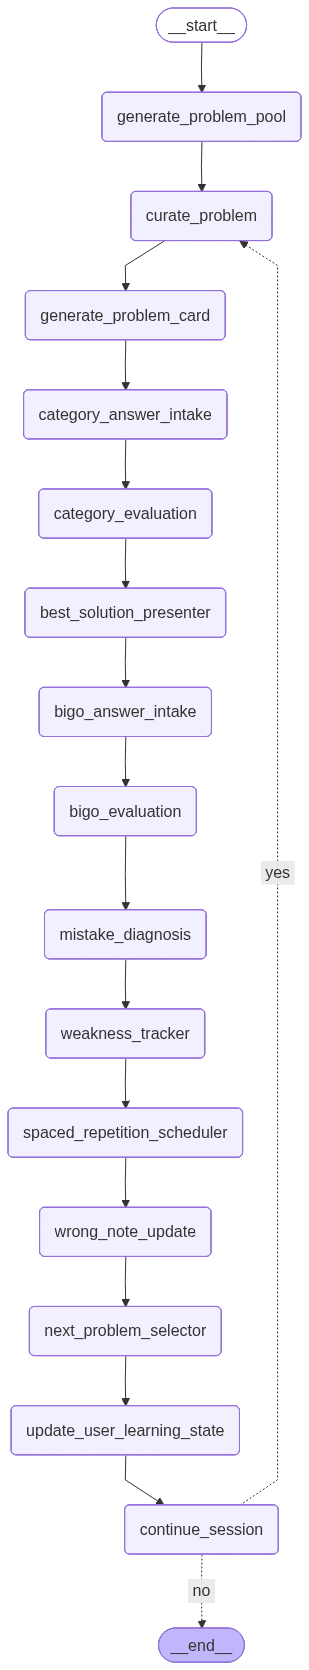

In [23]:
def build_graph():
    g = StateGraph(LearningState)

    # nodes
    g.add_node("select_study_mode", select_study_mode_node)
    g.add_node("generate_problem_pool", generate_problem_pool_node)
    g.add_node("curate_problem", problem_curation_node)
    g.add_node("generate_problem_card", problem_card_generator_node)

    # Pattern mode
    g.add_node("pattern_answer_intake", category_answer_intake_node)
    g.add_node("pattern_evaluate_answer", category_evaluation_node)

    # Big-O drill mode
    g.add_node("best_solution_presenter", best_solution_presenter_node)
    g.add_node("bigo_answer_intake", bigo_answer_intake_node)
    g.add_node("evaluate_bigo", bigo_evaluation_node)

    # Follow-up mode
    g.add_node("followup_question_generator", followup_question_generator_node)
    g.add_node("followup_user_response_intake", followup_user_response_intake_node)
    g.add_node("followup_evaluation", followup_evaluation_node)

    # shared post processing
    g.add_node("mistake_diagnosis", mistake_diagnosis_node)
    g.add_node("weakness_tracker", weakness_tracker_node)
    g.add_node("spaced_repetition_scheduler", spaced_repetition_scheduler_node)
    g.add_node("wrong_note_update", wrong_note_update_node)
    g.add_node("recommend_next_card", recommend_next_card_node)
    g.add_node("continue_session", continue_session_node)

    # edges
    g.add_edge(START, "select_study_mode")
    g.add_edge("select_study_mode", "generate_problem_pool")
    g.add_edge("generate_problem_pool", "curate_problem")
    g.add_edge("curate_problem", "generate_problem_card")

    # branch by study mode
    g.add_conditional_edges(
        "generate_problem_card",
        _mode_router,
        {
            "pattern": "pattern_answer_intake",
            "bigo": "best_solution_presenter",
            "followup": "followup_question_generator",
        },
    )

    # Pattern flow
    g.add_edge("pattern_answer_intake", "pattern_evaluate_answer")
    g.add_edge("pattern_evaluate_answer", "mistake_diagnosis")

    # Big-O flow
    g.add_edge("best_solution_presenter", "bigo_answer_intake")
    g.add_edge("bigo_answer_intake", "evaluate_bigo")
    g.add_edge("evaluate_bigo", "mistake_diagnosis")

    # Follow-up flow
    g.add_edge("followup_question_generator", "followup_user_response_intake")
    g.add_edge("followup_user_response_intake", "followup_evaluation")
    g.add_edge("followup_evaluation", "weakness_tracker")

    # shared tail
    g.add_edge("mistake_diagnosis", "weakness_tracker")
    g.add_edge("weakness_tracker", "spaced_repetition_scheduler")
    g.add_edge("spaced_repetition_scheduler", "wrong_note_update")
    g.add_edge("wrong_note_update", "recommend_next_card")
    g.add_edge("recommend_next_card", "continue_session")

    g.add_conditional_edges(
        "continue_session",
        _continue_router,
        {
            "yes": "curate_problem",
            "no": END,
        },
    )

    return g.compile()


app = build_graph()

app

In [24]:
initial_state: LearningState = {
    "user_profile": DEFAULT_PROFILE,

    # study mode
    # 0=pattern, 1=bigo, 2=followup
    "study_mode_selected_index": 0,

    # follow-up mode (free-text)
    "followup_user_response": "I would handle edge cases (empty input), confirm constraints, and discuss trade-offs.",

    # session control
    "session_day": 0,
    "turn_index": 0,
    "max_turns": 2,

    # spaced repetition + notes
    "review_schedule": {},
    "wrong_notes": {},
    "due_review_ids": ["lc_20_valid_parentheses"],

    # Simulated user answers (MCQ indices)
    "category_selected_index": 0,
    "bigo_selected_time_index": 0,
    "bigo_selected_space_index": 0,
}

final_state = app.invoke(initial_state)

{
    "study_mode_mcq": final_state.get("study_mode_mcq"),
    "study_mode": final_state.get("study_mode"),
    "selected_problem": final_state.get("selected_problem"),
    "problem_card": final_state.get("problem_card"),

    # pattern mode
    "category_mcq": final_state.get("category_mcq"),
    "category_selected": final_state.get("category_selected"),
    "expected_category": final_state.get("expected_category"),
    "category_is_correct": final_state.get("category_is_correct"),

    # big-o drill mode
    "best_solution": final_state.get("best_solution"),
    "expected_bigo": {
        "time": final_state.get("expected_bigo_time"),
        "space": final_state.get("expected_bigo_space"),
    },
    "bigo_mcq_time": final_state.get("bigo_mcq_time"),
    "bigo_mcq_space": final_state.get("bigo_mcq_space"),
    "bigo_selected": {
        "time": final_state.get("bigo_selected_time"),
        "space": final_state.get("bigo_selected_space"),
    },
    "bigo_is_correct": final_state.get("bigo_is_correct"),

    # follow-up mode
    "followup_questions": final_state.get("followup_questions"),
    "followup_is_correct": final_state.get("followup_is_correct"),
    "followup_feedback": final_state.get("followup_feedback"),

    # shared
    "mistake_diagnosis": final_state.get("mistake_diagnosis"),
    "wrong_notes_count": {k: len(v) for k, v in final_state.get("wrong_notes", {}).items()},
    "review_schedule": final_state.get("review_schedule"),
    "recommended_next_card": final_state.get("recommended_next_card"),
    "turn_index": final_state.get("turn_index"),
}


{'selected_problem': {'id': 'lc_number_of_islands',
  'title': 'Number of Islands',
  'slug': 'number-of-islands',
  'url': 'https://leetcode.com/problems/number-of-islands/',
  'categories': ['graph', 'dfs_bfs'],
  'difficulty': 'Medium',
  'interview_freq': 0.94},
 'category_mcq': {'prompt': 'Select the best primary solution category for: Number of Islands',
  'options': ['queue', 'dp', 'array', 'graph', 'greedy']},
 'category_selected': 'queue',
 'expected_category': 'dfs_bfs',
 'category_is_correct': False,
 'expected_bigo': {'time': 'O(n^2)', 'space': 'O(n^2)'},
 'bigo_mcq_time': {'prompt': 'Select the expected TIME complexity of the optimal solution:',
  'options': ['O(1)', 'O(n^3)', 'O(log n)', 'O(n log n)', 'O(n^2)']},
 'bigo_mcq_space': {'prompt': 'Select the expected SPACE complexity of the optimal solution:',
  'options': ['O(log n)', 'O(n^2)', 'O(n log n)', 'O(n^3)', 'O(n)']},
 'bigo_selected': {'time': 'O(1)', 'space': 'O(log n)'},
 'bigo_is_correct': False,
 'mistake_diag

In [25]:
def spaced_repetition_scheduler_node(state: LearningState) -> LearningState:
    """Very small SR scheduler (SM-2 inspired, simplified).

    Updates:
    - review_schedule[problem_id] = {due_day, interval, ease}
    - due_review_ids: list of problems due today (session_day)
    """

    profile = state.get("user_profile", DEFAULT_PROFILE)
    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]
    day = int(state.get("session_day", 0))

    schedule = dict(state.get("review_schedule", {}))
    entry = dict(schedule.get(pid, {"due_day": day, "interval": 1, "ease": 2.3}))

    # treat any wrong signal as "fail"
    cat_ok = bool(state.get("category_is_correct", False))
    bigo_ok = bool(state.get("bigo_is_correct", False))
    success = cat_ok and bigo_ok

    if success:
        ease = float(entry.get("ease", 2.3))
        interval = int(entry.get("interval", 1))
        interval = max(1, int(round(interval * ease)))
        due_day = day + interval
        entry.update({"ease": min(2.8, ease + 0.05), "interval": interval, "due_day": due_day})
    else:
        # reset for quick relearn
        entry.update({"ease": max(1.7, float(entry.get("ease", 2.3)) - 0.2), "interval": 1, "due_day": day + 1})

    schedule[pid] = entry

    # compute what's due today
    due_today = [k for k, v in schedule.items() if int(v.get("due_day", 10**9)) <= day]

    return {**state, "review_schedule": schedule, "due_review_ids": due_today}


def wrong_note_update_node(state: LearningState) -> LearningState:
    """Store mistake diagnosis into per-problem wrong notes."""

    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]
    notes = dict(state.get("wrong_notes", {}))
    notes_for_problem = list(notes.get(pid, []))

    cat_ok = bool(state.get("category_is_correct", False))
    bigo_ok = bool(state.get("bigo_is_correct", False))

    if not (cat_ok and bigo_ok):
        notes_for_problem.append(
            {
                "session_day": int(state.get("session_day", 0)),
                "category": {
                    "selected": state.get("category_selected"),
                    "expected": state.get("expected_category"),
                },
                "bigo": {
                    "selected": {
                        "time": state.get("bigo_selected_time"),
                        "space": state.get("bigo_selected_space"),
                    },
                    "expected": {
                        "time": state.get("expected_bigo_time"),
                        "space": state.get("expected_bigo_space"),
                    },
                },
                "diagnosis": state.get("mistake_diagnosis"),
            }
        )

    notes[pid] = notes_for_problem
    return {**state, "wrong_notes": notes}


def next_problem_selector_node(state: LearningState) -> LearningState:
    """Placeholder selector.

    The actual next problem is picked by looping back to `curate_problem`.
    This node exists to match the full design and to be a natural hook point
    for future recommendation logic.
    """

    return state


def update_user_learning_state_node(state: LearningState) -> LearningState:
    """Update solved/wrong history and advance turn counters."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    p = state.get("selected_problem")
    if not p:
        return state

    pid = p["id"]

    solved_ids = list(profile.get("solved_ids", []))
    wrong_ids = list(profile.get("wrong_ids", []))

    cat_ok = bool(state.get("category_is_correct", False))
    bigo_ok = bool(state.get("bigo_is_correct", False))
    success = cat_ok and bigo_ok

    if success:
        if pid not in solved_ids:
            solved_ids.append(pid)
    else:
        if pid not in wrong_ids:
            wrong_ids.append(pid)

    new_profile: UserProfile = {**profile, "solved_ids": solved_ids, "wrong_ids": wrong_ids}

    turn_index = int(state.get("turn_index", 0)) + 1
    max_turns = int(state.get("max_turns", 1))

    return {**state, "user_profile": new_profile, "turn_index": turn_index, "max_turns": max_turns}


def continue_session_node(state: LearningState) -> LearningState:
    """Decide whether to continue.

    In a UI, this can be replaced by an explicit user prompt.
    In this notebook we continue until `turn_index >= max_turns`.
    """

    turn_index = int(state.get("turn_index", 0))
    max_turns = int(state.get("max_turns", 1))

    return {**state, "continue_session": turn_index < max_turns}


def _continue_router(state: LearningState) -> str:
    return "yes" if state.get("continue_session") else "no"
